<a href="https://colab.research.google.com/github/ligafinancefiap-svg/core-finance-lib/blob/main/03_Data_Lake_Analise_Quant_Bancos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Segmento - Bancos - Transformação de dados

Camada Gold

*   Métricas de Risco
*   Matriz Correlação
*   Relatório de Decisão



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Conexão e Caminhos
drive.mount('/content/drive')
segmento = "bancos"
caminho_silver = f'/content/drive/MyDrive/DATA_LAKE/02_Silver/b3_{segmento}_limpo.csv'
caminho_gold = f'/content/drive/MyDrive/DATA_LAKE/03_Gold/b3_{segmento}_analise.csv'

# 2. Carregamento dos dados limpos
df = pd.read_csv(caminho_silver, index_col=0, parse_dates=True)

# --- PARTE QUANT ---

# A. Cálculo de Log-Retornos (Fundamental para análise estatística)
log_retornos = np.log(df / df.shift(1)).dropna()

# B. Métricas Anualizadas (Considerando 252 dias úteis)
retorno_anual = log_retornos.mean() * 252
vol_anual = log_retornos.std() * np.sqrt(252)
sharpe_ratio = retorno_anual / vol_anual # (Considerando Risk-free = 0)

# C. Matriz de Correlação
correlacao = log_retornos.corr()

# 3. Criação da Tabela Gold (Ouro para decisão)
df_gold = pd.DataFrame({
    'Retorno Anualizado (%)': (retorno_anual * 100).round(2),
    'Volatilidade Anual (%)': (vol_anual * 100).round(2),
    'Indice Sharpe': sharpe_ratio.round(2)
}).sort_values(by='Indice Sharpe', ascending=False)

# 4. Salvamento na Camada Gold
df_gold.to_csv(caminho_gold)
print(f"✅ Camada GOLD finalizada para {segmento.upper()}!")
print("\n🏆 RANKING DE EFICIÊNCIA (SHARPE):")
print(df_gold)

Mounted at /content/drive
✅ Camada GOLD finalizada para BANCOS!

🏆 RANKING DE EFICIÊNCIA (SHARPE):
        Retorno Anualizado (%)  Volatilidade Anual (%)  Indice Sharpe
ITUB4                    17.90                   25.15           0.71
BBAS3                    18.52                   26.70           0.69
BPAC11                   20.96                   35.17           0.60
BBDC4                     6.13                   29.98           0.20
SANB11                    3.08                   26.54           0.12


Evolução da volatilidade


📅 RETORNO LOGÍSTICO MENSAL (Últimos 6 meses):
            BBAS3  BBDC4  BPAC11  ITUB4  SANB11
Date                                           
2025-10-31  -0.86   2.73    1.15   0.99    7.63
2025-11-30   2.57   7.99   10.08   5.47    9.37
2025-12-31  -1.95  -5.51   -1.44   2.60   -0.41
2026-01-31  14.02  15.93   13.12  14.87    8.51
2026-02-28   7.46  -0.67    2.16   2.81   -8.08
2026-03-31  -9.72  -9.53   -9.93  -9.46   -7.50


<Figure size 1200x600 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


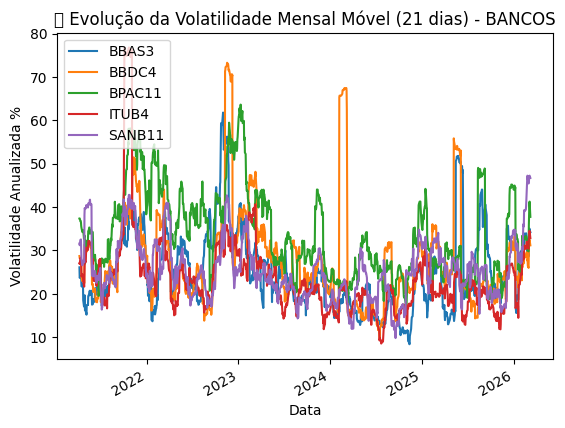

In [2]:
# --- ANÁLISE TEMPORAL (MENSAL E MÓVEL) ---

# 1. Retorno Mensal Acumulado (Tabela para Projeções)
# Agrupa por mês e calcula o retorno
retorno_mensal = log_retornos.resample('ME').sum()
print("\n📅 RETORNO LOGÍSTICO MENSAL (Últimos 6 meses):")
print((retorno_mensal.tail(6) * 100).round(2))

# 2. Volatilidade Móvel (Janela de 21 dias úteis = 1 mês)
# Isso mostra como o risco evoluiu ao longo do tempo
vol_movel = log_retornos.rolling(window=21).std() * np.sqrt(252) * 100

# 3. Gráfico de Evolução do Risco (Volatilidade)
plt.figure(figsize=(12, 6))
vol_movel.plot()
plt.title(f"📊 Evolução da Volatilidade Mensal Móvel (21 dias) - {segmento.upper()}")
plt.ylabel("Volatilidade Anualizada %")
plt.xlabel("Data")
plt.legend(loc='upper left')
plt.show()

# 4. Salvamento da Tabela Mensal na Gold (Para suas projeções em Excel ou BI)
retorno_mensal.to_csv(f'/content/drive/MyDrive/DATA_LAKE/03_Gold/b3_{segmento}_retorno_mensal.csv')